# Taller 08 - Random Forest

## Clasificación de dígitos escritos con el dataset `digits` de Scikit-learn

**Objetivo:** diseñar e implementar un Random Forest que clasifique los dígitos del dataset `digits`, usando 80 % de los datos para entrenamiento, 20 % para prueba y K-fold = 4 durante el proceso de selección de parámetros.

Además, se estudiará `ccp_alpha` para controlar la complejidad de los árboles y se buscará una configuración con un número reducido de árboles y árboles de menor tamaño, manteniendo un buen rendimiento y evitando un aumento innecesario del sobreajuste.

## 1. Importación de las bibliotecas

Se importan las herramientas necesarias para cargar el dataset, separar los datos, realizar validación cruzada, construir el Random Forest, medir el rendimiento y visualizar los resultados.

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

## 2. Carga del dataset `digits`

El dataset `digits` viene incluido dentro de Scikit-learn, por lo que no es necesario descargar un archivo externo. Contiene imágenes de dígitos escritos a mano.

Cada imagen tiene un tamaño de 8 × 8 píxeles, es decir, 64 características. Las etiquetas (`target`) corresponden a los números del 0 al 9.

In [20]:
# Cargamos el dataset de dígitos incluido en Scikit-learn.
digits = load_digits()

# X contiene las características de las imágenes.
X = digits.data

# y contiene la clase o dígito correcto de cada imagen.
y = digits.target

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)
print("Clases disponibles:", np.unique(y))

Dimensiones de X: (1797, 64)
Dimensiones de y: (1797,)
Clases disponibles: [0 1 2 3 4 5 6 7 8 9]


## 3. Visualización de algunos dígitos

Antes de entrenar el modelo, observamos ejemplos del conjunto de datos. Esto permite comprobar visualmente qué información intenta aprender el clasificador.

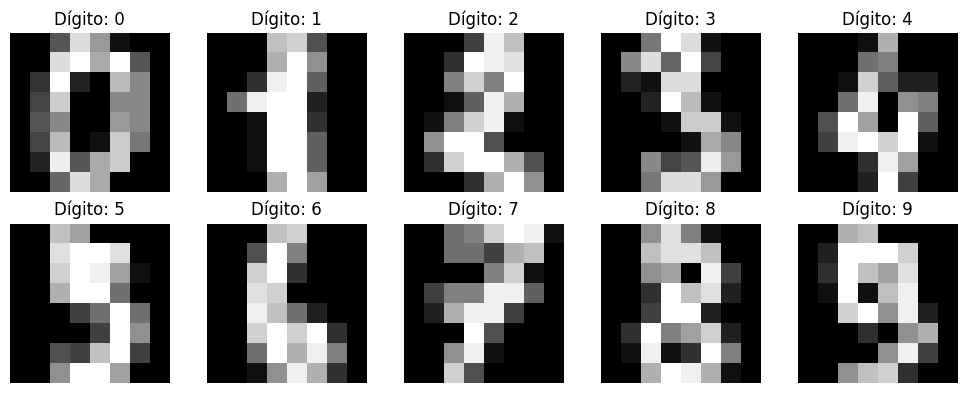

In [21]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for ax, image, label in zip(axes.ravel(), digits.images[:10], digits.target[:10]):
    ax.imshow(image, cmap="gray")
    ax.set_title(f"Dígito: {label}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## 4. División 80 % entrenamiento y 20 % prueba

El taller exige utilizar 80 % de los datos para entrenamiento y 20 % para prueba.

El conjunto de prueba se reserva hasta el final. Durante la selección de parámetros se utilizará solamente el conjunto de entrenamiento mediante K-fold = 4.

In [22]:
# 80 % para entrenamiento y 20 % para prueba.
# stratify=y conserva aproximadamente la misma proporción de cada dígito.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (1437, 64)
Datos de prueba: (360, 64)


## 5. Configuración de K-fold = 4

Se utiliza validación cruzada estratificada con 4 particiones. En cada ronda se entrenará con 3 partes y se validará con la parte restante. El proceso se repite cuatro veces y se calcula el promedio del accuracy.

Esto permite comparar configuraciones del Random Forest sin utilizar el conjunto de prueba para tomar la decisión.

In [23]:
# K-fold = 4, manteniendo la proporción de las clases en cada partición.
cv = StratifiedKFold(
    n_splits=4,
    shuffle=True,
    random_state=42
)

print("Número de folds:", cv.get_n_splits())

Número de folds: 4


## 6. ¿Qué significa `ccp_alpha`?

El parámetro `ccp_alpha` controla la poda por costo-complejidad (*Minimal Cost-Complexity Pruning*).

La idea es penalizar la complejidad del árbol. Cuando `ccp_alpha = 0`, no se añade penalización por complejidad. Al aumentar `ccp_alpha`, aumenta la poda y los árboles tienden a tener menos nodos, menos hojas y menor profundidad.

**Idea principal:**

`ccp_alpha` ↑ → más poda → árboles más pequeños → menor complejidad.

En un Random Forest, el parámetro se aplica a los árboles que forman el bosque.

## 7. Obtener valores candidatos de `ccp_alpha` con un árbol de referencia

El cuaderno proporcionado por el profesor muestra que `DecisionTreeClassifier` puede calcular los valores relevantes de poda mediante `cost_complexity_pruning_path`.

Usamos un árbol de referencia únicamente para observar valores candidatos. Posteriormente, esos valores se prueban directamente en el `RandomForestClassifier`.

In [24]:
# Árbol de referencia para estudiar los valores de poda.
tree_reference = DecisionTreeClassifier(random_state=42)

# Obtenemos la trayectoria de poda calculada a partir del entrenamiento.
path = tree_reference.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas_reference = np.unique(path.ccp_alphas)

print("Cantidad de valores candidatos obtenidos:", len(ccp_alphas_reference))
print("Primeros valores candidatos:")
print(ccp_alphas_reference[:15])

Cantidad de valores candidatos obtenidos: 93
Primeros valores candidatos:
[0.         0.00068816 0.00069589 0.00069589 0.00092786 0.00104384
 0.00111343 0.00119296 0.00127581 0.001299   0.001299   0.00131728
 0.00132551 0.00135024 0.00135784]


## 8. Definición de los valores que se probarán en Random Forest

Para el experimento utilizamos varios valores de `ccp_alpha` alrededor de la zona en la que la poda empieza a reducir la complejidad sin destruir demasiado el rendimiento.

También probamos diferentes cantidades de árboles. De esta forma podemos estudiar simultáneamente las dos condiciones principales del taller: reducir el número de árboles y reducir el tamaño de los árboles.

In [25]:
# Cantidades de árboles que se evaluarán.
n_estimators_values = [30, 40, 50, 60, 70, 80, 90, 100, 150, 200]

# Valores de ccp_alpha que se evaluarán.
ccp_alpha_values = [0, 0.001, 0.002, 0.003, 0.004, 0.005, 0.0075, 0.01]

print("Número de árboles evaluados:", n_estimators_values)
print("Valores de ccp_alpha evaluados:", ccp_alpha_values)

Número de árboles evaluados: [30, 40, 50, 60, 70, 80, 90, 100, 150, 200]
Valores de ccp_alpha evaluados: [0, 0.001, 0.002, 0.003, 0.004, 0.005, 0.0075, 0.01]


## 9. Experimento con K-fold = 4

Para cada combinación de `n_estimators` y `ccp_alpha` entrenamos un Random Forest mediante validación cruzada de 4 folds.

Guardamos:
- accuracy de entrenamiento;
- accuracy de validación;
- desviación estándar de la validación;
- tiempo promedio de entrenamiento.

Después, para medir el tamaño de los árboles, entrenamos la configuración sobre todo el conjunto de entrenamiento y calculamos la profundidad, número de nodos y número de hojas promedio.

In [26]:
resultados = []

for alpha in ccp_alpha_values:
    for n_trees in n_estimators_values:
        # Creamos el Random Forest con la combinación actual.
        modelo = RandomForestClassifier(
            n_estimators=n_trees,
            ccp_alpha=alpha,
            criterion="gini",
            max_features="sqrt",
            random_state=42,
            n_jobs=-1
        )

        # Validación cruzada de 4 folds.
        scores = cross_validate(
            modelo,
            X_train,
            y_train,
            cv=cv,
            scoring="accuracy",
            return_train_score=True,
            n_jobs=1
        )

        # Entrenamos una vez sobre todo el conjunto de entrenamiento
        # para medir la complejidad promedio de los árboles.
        modelo.fit(X_train, y_train)

        profundidades = [arbol.tree_.max_depth for arbol in modelo.estimators_]
        nodos = [arbol.tree_.node_count for arbol in modelo.estimators_]
        hojas = [arbol.tree_.n_leaves for arbol in modelo.estimators_]

        resultados.append({
            "ccp_alpha": alpha,
            "n_estimators": n_trees,
            "train_accuracy_cv": scores["train_score"].mean(),
            "val_accuracy_cv": scores["test_score"].mean(),
            "val_std": scores["test_score"].std(),
            "fit_time": scores["fit_time"].mean(),
            "depth_mean": np.mean(profundidades),
            "nodes_mean": np.mean(nodos),
            "leaves_mean": np.mean(hojas)
        })

resultados_df = pd.DataFrame(resultados)

print("Cantidad de configuraciones evaluadas:", len(resultados_df))

Cantidad de configuraciones evaluadas: 80


## 10. Comparación de las configuraciones

Ordenamos las configuraciones por accuracy promedio de validación. Este es el indicador principal para comparar el rendimiento durante la selección.

In [27]:
tabla_resultados = resultados_df.sort_values(
    by="val_accuracy_cv",
    ascending=False
).reset_index(drop=True)

tabla_resultados.head(15)

,ccp_alpha,n_estimators,train_accuracy_cv,val_accuracy_cv,val_std,fit_time,depth_mean,nodes_mean,leaves_mean
0,0.000,200,1.000000,0.975644,0.004971,0.769454,13.460000,343.040000,172.020000
1,0.000,100,1.000000,0.972166,0.002764,0.608409,13.280000,340.020000,170.510000
2,0.001,200,1.000000,0.972164,0.005909,0.806729,12.590000,281.500000,141.250000
3,0.001,100,1.000000,0.972164,0.003412,0.396020,12.410000,278.900000,139.950000
4,0.000,90,1.000000,0.971470,0.003606,0.362385,13.288889,340.133333,170.566667
5,0.002,200,0.999768,0.971470,0.004109,1.114974,11.235000,178.910000,89.955000
6,0.001,80,1.000000,0.970773,0.006066,0.326239,12.400000,278.125000,139.562500
7,0.000,150,1.000000,0.970773,0.002400,0.580735,13.386667,340.520000,170.760000
8,0.001,90,1.000000,0.970773,0.003105,0.360078,12.433333,278.777778,139.888889
9,0.002,150,0.999768,0.970079,0.003596,0.588278,11.213333,178.133333,89.566667


## 11. Gráfica: accuracy de validación según el número de árboles

La gráfica permite observar si aumentar el número de árboles produce mejoras importantes o si llega un punto en el que el rendimiento se estabiliza.

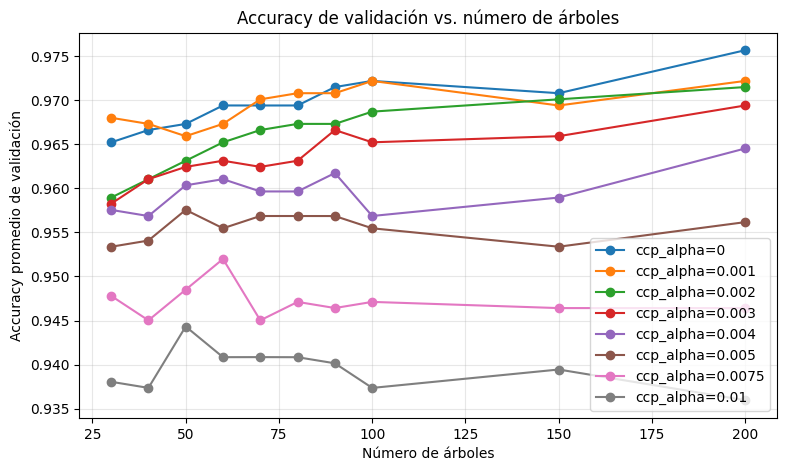

In [28]:
plt.figure(figsize=(9, 5))

for alpha in ccp_alpha_values:
    datos_alpha = resultados_df[resultados_df["ccp_alpha"] == alpha]
    plt.plot(
        datos_alpha["n_estimators"],
        datos_alpha["val_accuracy_cv"],
        marker="o",
        label=f"ccp_alpha={alpha}"
    )

plt.xlabel("Número de árboles")
plt.ylabel("Accuracy promedio de validación")
plt.title("Accuracy de validación vs. número de árboles")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 12. Selección de la configuración final

El taller pide buscar el mínimo número de árboles posible manteniendo buenos indicadores. Para hacer esta decisión de forma explícita, primero encontramos el mejor accuracy de validación y después aceptamos configuraciones que estén como máximo **0.5 puntos porcentuales** por debajo de ese máximo.

Dentro de ese grupo elegimos primero el menor número de árboles. Si hubiera empate, se prefiere el mayor `ccp_alpha`, porque representa una poda mayor y, por tanto, árboles potencialmente más pequeños.

Esta regla evita escoger automáticamente el bosque más grande solo porque obtiene unas centésimas más de accuracy.

In [29]:
# Mejor accuracy de validación encontrado.
mejor_val_accuracy = resultados_df["val_accuracy_cv"].max()

# Tolerancia de 0.5 puntos porcentuales = 0.005 en escala 0-1.
tolerancia = 0.005

# Nos quedamos con configuraciones prácticamente equivalentes al mejor resultado.
candidatos_finales = resultados_df[
    resultados_df["val_accuracy_cv"] >= mejor_val_accuracy - tolerancia
].copy()

# Primero minimizamos el número de árboles y luego maximizamos ccp_alpha.
seleccion = candidatos_finales.sort_values(
    by=["n_estimators", "ccp_alpha"],
    ascending=[True, False]
).iloc[0]

mejor_n_estimators = int(seleccion["n_estimators"])
mejor_ccp_alpha = float(seleccion["ccp_alpha"])

print("Mejor accuracy de validación:", round(mejor_val_accuracy, 4))
print("Configuración seleccionada:")
print("  n_estimators =", mejor_n_estimators)
print("  ccp_alpha    =", mejor_ccp_alpha)
print("  val_accuracy =", round(seleccion["val_accuracy_cv"], 4))
print("  profundidad promedio =", round(seleccion["depth_mean"], 2))
print("  nodos promedio       =", round(seleccion["nodes_mean"], 2))
print("  hojas promedio       =", round(seleccion["leaves_mean"], 2))

Mejor accuracy de validación: 0.9756
Configuración seleccionada:
  n_estimators = 80
  ccp_alpha    = 0.001
  val_accuracy = 0.9708
  profundidad promedio = 12.4
  nodos promedio       = 278.12
  hojas promedio       = 139.56


## 13. Análisis del efecto de `ccp_alpha`

Ahora mantenemos fijo el número de árboles seleccionado y observamos cómo cambia el tamaño de los árboles al aumentar `ccp_alpha`.

Esperamos encontrar que valores mayores de `ccp_alpha` produzcan árboles progresivamente más pequeños. Sin embargo, una poda excesiva puede disminuir demasiado el rendimiento y producir subajuste.

In [30]:
analisis_poda = resultados_df[
    resultados_df["n_estimators"] == mejor_n_estimators
].sort_values("ccp_alpha")

display(
    analisis_poda[
        ["ccp_alpha", "val_accuracy_cv", "train_accuracy_cv",
         "depth_mean", "nodes_mean", "leaves_mean"]
    ]
)

,ccp_alpha,val_accuracy_cv,train_accuracy_cv,depth_mean,nodes_mean,leaves_mean
5,0.0000,0.969383,1.000000,13.2250,338.975,169.9875
15,0.0010,0.970773,1.000000,12.4000,278.125,139.5625
25,0.0020,0.967295,0.999536,11.2375,176.875,88.9375
35,0.0030,0.963119,0.998376,10.2500,127.775,64.3875
45,0.0040,0.959639,0.994433,9.5500,98.375,49.6875
55,0.0050,0.956854,0.988402,8.9625,80.325,40.6625
65,0.0075,0.947120,0.976109,7.8125,54.075,27.5375
75,0.0100,0.940852,0.962886,7.0000,41.375,21.1875


## 14. Gráfica de complejidad de los árboles

La siguiente gráfica muestra cómo cambia el número promedio de nodos al modificar `ccp_alpha`. Una reducción del número de nodos significa que los árboles son más pequeños.

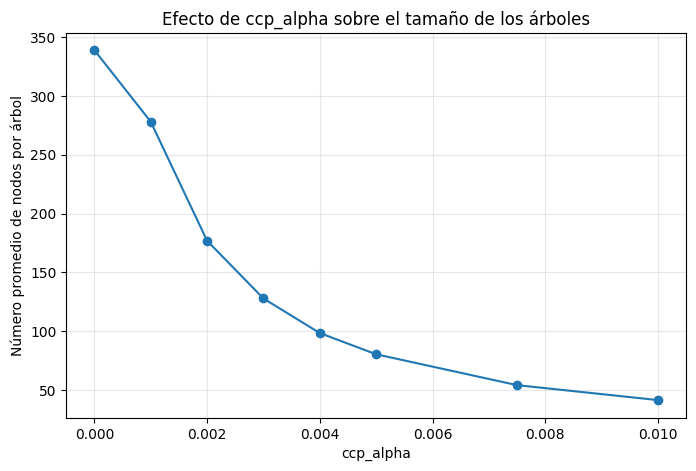

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(
    analisis_poda["ccp_alpha"],
    analisis_poda["nodes_mean"],
    marker="o"
)
plt.xlabel("ccp_alpha")
plt.ylabel("Número promedio de nodos por árbol")
plt.title("Efecto de ccp_alpha sobre el tamaño de los árboles")
plt.grid(True, alpha=0.3)
plt.show()

## 15. Entrenamiento del Random Forest definitivo

Una vez seleccionados los hiperparámetros mediante K-fold = 4, entrenamos el modelo definitivo utilizando todo el conjunto de entrenamiento (80 % del dataset).

El conjunto de prueba permanece separado y se utiliza solamente para la evaluación final.

In [32]:
modelo_final = RandomForestClassifier(
    n_estimators=mejor_n_estimators,
    ccp_alpha=mejor_ccp_alpha,
    criterion="gini",
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

# Entrenamos usando todos los datos destinados al entrenamiento.
modelo_final.fit(X_train, y_train)

print("Modelo final entrenado correctamente.")

Modelo final entrenado correctamente.


## 16. Predicciones y accuracy final

Ahora el modelo clasifica las imágenes del conjunto de prueba, que no fueron utilizadas durante el entrenamiento ni durante la selección de hiperparámetros.

In [33]:
# Predicciones sobre entrenamiento y prueba.
y_pred_train = modelo_final.predict(X_train)
y_pred_test = modelo_final.predict(X_test)

accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_test = accuracy_score(y_test, y_pred_test)

print(f"Accuracy entrenamiento: {accuracy_train:.4f}")
print(f"Accuracy prueba:        {accuracy_test:.4f}")
print(f"Diferencia:             {accuracy_train - accuracy_test:.4f}")

Accuracy entrenamiento: 1.0000
Accuracy prueba:        0.9583
Diferencia:             0.0417


## 17. Evaluación detallada: precision, recall y F1-score

El `classification_report` permite analizar el rendimiento por cada dígito. Además del accuracy global, se muestran precision, recall y F1-score.

In [34]:
print(classification_report(y_test, y_pred_test, digits=4))

              precision    recall  f1-score   support

           0     0.9722    0.9722    0.9722        36
           1     0.8974    0.9722    0.9333        36
           2     1.0000    0.9714    0.9855        35
           3     0.9722    0.9459    0.9589        37
           4     0.9722    0.9722    0.9722        36
           5     0.9737    1.0000    0.9867        37
           6     1.0000    0.9722    0.9859        36
           7     0.9231    1.0000    0.9600        36
           8     0.9091    0.8571    0.8824        35
           9     0.9706    0.9167    0.9429        36

    accuracy                         0.9583       360
   macro avg     0.9591    0.9580    0.9580       360
weighted avg     0.9592    0.9583    0.9582       360



## 18. Matriz de confusión

La matriz de confusión muestra cuántos ejemplos de cada dígito fueron clasificados correctamente y qué dígitos fueron confundidos entre sí.

Los valores de la diagonal principal representan las clasificaciones correctas.

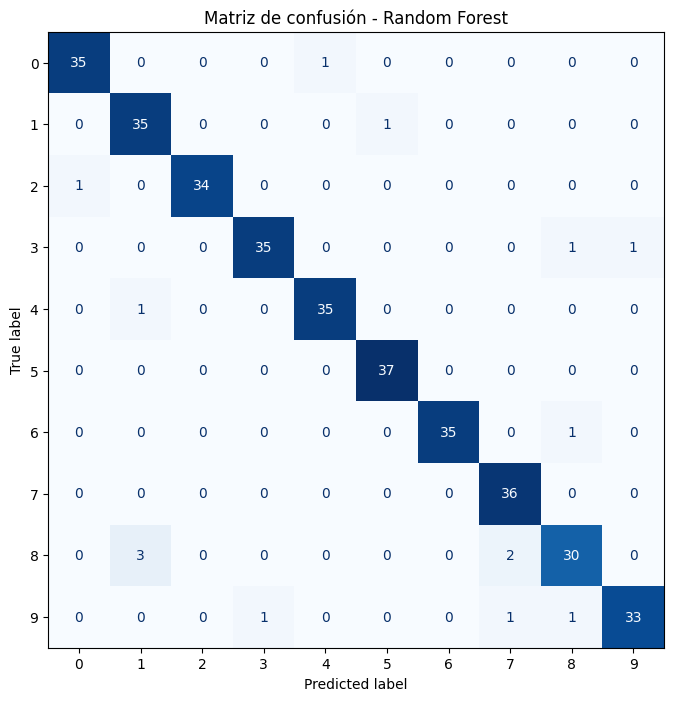

In [35]:
cm = confusion_matrix(y_test, y_pred_test)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=np.arange(10)
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Matriz de confusión - Random Forest")
plt.show()

## 19. Tamaño final de los árboles

Finalmente calculamos la profundidad, número de nodos y número de hojas de los árboles del bosque seleccionado. Estos valores permiten justificar la reducción de complejidad producida por `ccp_alpha`.

In [36]:
profundidades_final = [arbol.tree_.max_depth for arbol in modelo_final.estimators_]
nodos_final = [arbol.tree_.node_count for arbol in modelo_final.estimators_]
hojas_final = [arbol.tree_.n_leaves for arbol in modelo_final.estimators_]

print("Número de árboles:", len(modelo_final.estimators_))
print("Profundidad promedio:", round(np.mean(profundidades_final), 2))
print("Profundidad máxima:", max(profundidades_final))
print("Nodos promedio por árbol:", round(np.mean(nodos_final), 2))
print("Hojas promedio por árbol:", round(np.mean(hojas_final), 2))

Número de árboles: 80
Profundidad promedio: 12.4
Profundidad máxima: 15
Nodos promedio por árbol: 278.12
Hojas promedio por árbol: 139.56


## 20. Conclusiones

1. El dataset `digits` de Scikit-learn contiene 1797 imágenes de dígitos, representadas mediante 64 características.
2. Se respetó la división solicitada de 80 % para entrenamiento y 20 % para prueba.
3. La selección de hiperparámetros se realizó utilizando K-fold = 4 sobre el conjunto de entrenamiento.
4. Se evaluaron diferentes cantidades de árboles y diferentes valores de `ccp_alpha`.
5. `ccp_alpha` se utilizó como mecanismo de poda posterior para reducir la complejidad de los árboles.
6. La selección final prioriza el menor número de árboles entre las configuraciones cuyo rendimiento de validación está prácticamente al nivel del mejor resultado.
7. El conjunto de prueba se utilizó únicamente después de seleccionar la configuración final, evitando utilizarlo para tomar decisiones durante el entrenamiento.

### Estrategia de poda

La estrategia consiste en aumentar `ccp_alpha` para penalizar árboles excesivamente complejos. Un valor demasiado pequeño deja árboles grandes, mientras que un valor demasiado grande puede producir subajuste. Por ello se compara el accuracy de validación con la complejidad de los árboles y se selecciona un punto de equilibrio.

### Nota

Los valores exactos de accuracy, profundidad y número de nodos pueden variar ligeramente según la versión de Scikit-learn y el entorno de ejecución. La metodología y el código permiten reproducir el experimento con `random_state=42`.